# 10 Seismic Equations

This notebook has origin from article named "TEN TRAVELTIME EQUATIONS IN SEISMICS:
COMPLETE DERIVATIONS AND APPLICATIONS", where 10 equations of seismic time travel where developed. The calculation of transit time is of great importance
for seismic processing and imaging. In thiswork, we gathered and reviewed the derivations of ten transit time equations which contains the calculations of transit times for: direct waves, waves reflected in a parallel and inclined plane medium, first-order multiples in a parallel and inclined plane medium, P-SV and SV-P converted waves, refracted waves in a parallel and inclined plane medium, diffracted waves in two cases, and for a 1D heterogeneous medium.

## Methodology

For the calculation of transit time, the following methodology was mainly used:

1) Define a model of two homogeneous and isotropic layers with velocities $v_1$ and $v_2$. The depth of the reflector is given by $z$.

2) Define $x$ as the distance between the source and receiver. The source is represented by a red star and the receiver is represented by a blue triangle.

3) Apply the idea of ​​an image point where the reflector is interpreted as a mirror and the source can then be projected to an equidistant location, facilitating the calculation of the ray's path in the case of multiple reflections.

4) Calculate the total path of the ray using trigonometry. The transit time can be found using the general equation:

$$ \text{travel time}=\dfrac{\text{total trajectory of the ray}}{\text{medium velocity}}$$

The main objective of this notebook is to present the modeling codes from equations described in the aforementioned article. For more detailed information we recomend it's reading.

For exemplification and visualization of code results, we defined:
 - x = 2500 meters and it's a set of 50 equidistant points.
 - z = 200 meters
 - v1 = 2100 meters per seconds (m/s)
 - v2 = 2900 meters per seconds (m/s)
 - $\theta$ = 30 degrees
 - $\alpha$ = 60 degrees
 - $\phi$ = 45 degrees

Importing libraries and variables

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
x=np.linspace(0, 2500, 50)
z=200
v1=vs1=2100
v2=vp1=2900
theta = np.deg2rad(30)
zu=150
alpha = np.deg2rad(60)
zd=zu+x*np.sin(alpha) 
phi = np.deg2rad(45)
h=20
hs=x+h
hr=x-h

# Gradient
v0=1500
a=5
zg=np.linspace(10,2000,50)
v=v0+a*zg
p=1/v

term_v0 = np.maximum(0, 1 - (p**2) * (v0**2))
term_v  = np.maximum(0, 1 - (p**2) * (v**2))

xg = (2 / (p * a)) * (np.sqrt(term_v0) - np.sqrt(term_v))



#### Ploting Function

In [3]:
def ploting_curves(x,time,time_name, title, fig_number):
    # ----------------------------------------------------
    # Graph plotting
    # ----------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 10))

    ax1.plot(x, time, 
        label=rf'$T_{{\mathrm{{{time_name}}}}}$', 
        color='dodgerblue', 
        marker='o', 
        alpha=0.7,
        markerfacecolor='dodgerblue',   # Cor de dentro do círculo
        markeredgecolor='black',       # Cor da borda do círculo (substitui edgecolors)
        markeredgewidth=1.2,           # Espessura da borda do círculo (substitui linewidths para o marcador)
        linewidth=1.5)  
    ax1.set_title(f'Travel Time of {title}', pad=20)
    ax1.set_ylabel('Travel Time (s)')
    ax1.set_xlabel('Offset (m)')

    # Graphs modifications
    ax1.invert_yaxis()
    ax1.xaxis.tick_top()
    ax1.xaxis.set_label_position('top')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # ----------------------------------------------------
    # External Figure
    # ----------------------------------------------------
    img_path = f'Figures/fig{fig_number}.png'
    img = mpimg.imread(img_path)
    ax2.imshow(img)

    ax2.axis('off') 

    plt.tight_layout()
    plt.show()


In [4]:
def ploting_curves2(x,time1,time2,time_name1,time_name2, title, fig_number):
    # ----------------------------------------------------
    # Graph plotting
    # ----------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 10))

    ax1.plot(x, time1, 
        label=rf'$T_{{\mathrm{{{time_name1}}}}}$', 
        color='dodgerblue', 
        marker='o', 
        alpha=0.7,
        markerfacecolor='dodgerblue',   # Cor de dentro do círculo
        markeredgecolor='black',       # Cor da borda do círculo (substitui edgecolors)
        markeredgewidth=1.2,           # Espessura da borda do círculo (substitui linewidths para o marcador)
        linewidth=1.5)  
    
    ax1.plot(x, time2, 
        label=rf'$T_{{\mathrm{{{time_name2}}}}}$', 
        color='red', 
        marker='o', 
        alpha=0.7,
        markerfacecolor='red',   # Cor de dentro do círculo
        markeredgecolor='black',       # Cor da borda do círculo (substitui edgecolors)
        markeredgewidth=1.2,           # Espessura da borda do círculo (substitui linewidths para o marcador)
        linewidth=1.5)  
    ax1.set_title(f'Travel Time of {title}', pad=20)
    ax1.set_ylabel('Travel Time (s)')
    ax1.set_xlabel('Offset (m)')

    # Graphs modifications
    ax1.invert_yaxis()
    ax1.xaxis.tick_top()
    ax1.xaxis.set_label_position('top')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # ----------------------------------------------------
    # External Figure
    # ----------------------------------------------------
    img_path = f'Figures/fig{fig_number}.png'
    img = mpimg.imread(img_path)
    ax2.imshow(img)

    ax2.axis('off') 

    plt.tight_layout()
    plt.show()


### 1) Traveltime of direct and reflected waves in a plane-parallel model

$$ T_{\text{direct}} = \dfrac{x}{v_1}$$

In [5]:
def foward_direct_wave(x,v1):
    t_direct=x/v1
    return t_direct

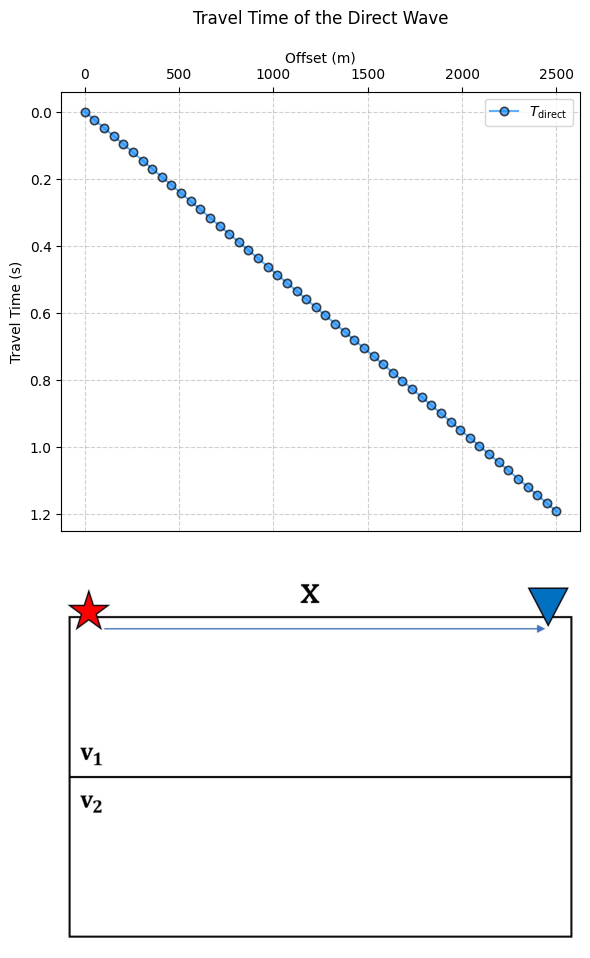

In [6]:
t_direct=foward_direct_wave(x,v1)
ploting_curves(x,t_direct,'direct',
               'the Direct Wave','02_1')

$$ T_{\text{reflected}} = \dfrac{\sqrt{(2z)^2+x^2}}{v_1}$$


In [7]:
def foward_reflected_wave(x,v1,z):
    sqrt_reflection=np.sqrt((2*z)**2+x**2)
    t_reflected=sqrt_reflection/v1
    return t_reflected

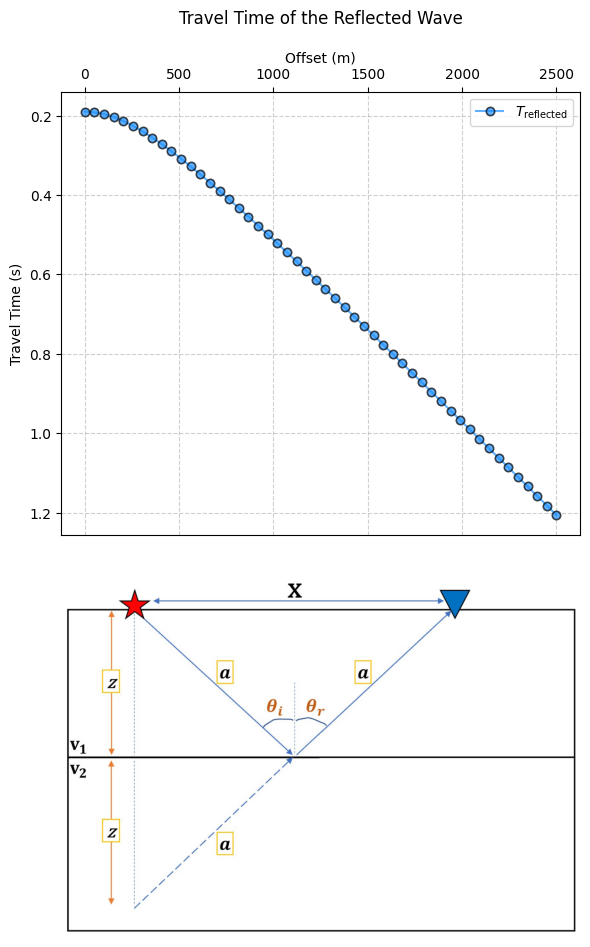

In [8]:
t_reflected=foward_reflected_wave(x,v1,z)
ploting_curves(x,t_reflected,'reflected',
               'the Reflected Wave','03_1')



### 2) Traveltime of first-order multiples for a plane-parallel event

$$ T_{\text{multiple}} = \dfrac{\sqrt{(4z)^2+x^2}}{v_1}$$


In [9]:
def foward_first_parallel_multiples(x,v1,z):
    sqrt_first=np.sqrt((4*z)**2+x**2)
    t_first=sqrt_first/v1
    return t_first

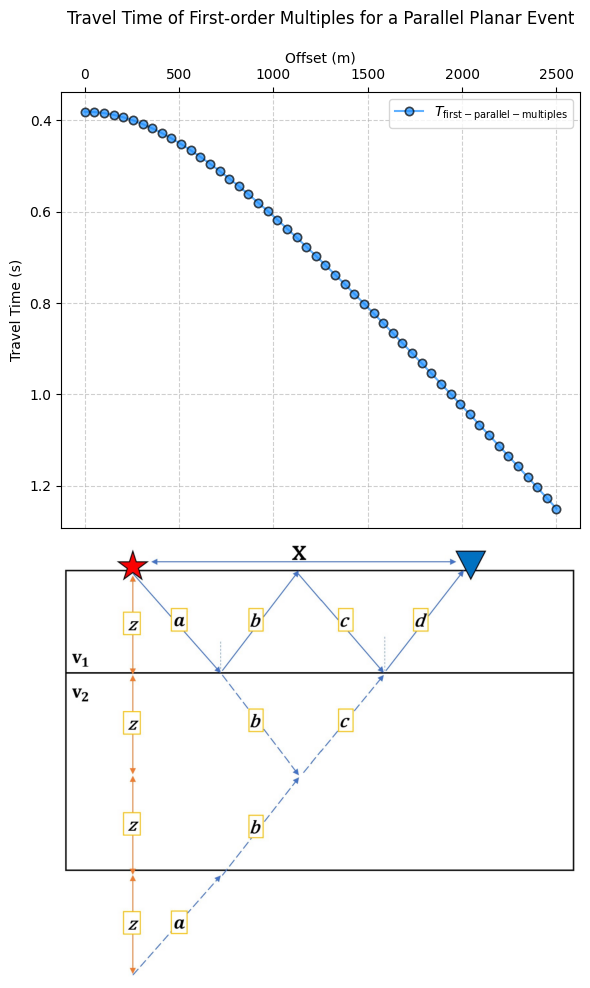

In [10]:
t_first_parallel_multiples=foward_first_parallel_multiples(x,v1,z)
ploting_curves(x,t_first_parallel_multiples,'first-parallel-multiples',
               'First-order Multiples for a Parallel Planar Event',
               '04_1')


### 3) Travel time of the reflected wave to a reflector plane with inclination $\theta$

$$ T_{\text{reflected-theta}} = \dfrac{\sqrt{(2z)^2+x^2+4\cdot z\cdot x\cdot \sin (\theta) }}{v_1}$$


In [11]:
def foward_reflected_plane_theta(x,v1,z,theta):
    sqrt_theta=np.sqrt((4*z)**2+x**2+4*z*x*np.sin(theta))
    t_reflected_theta=sqrt_theta/v1
    return t_reflected_theta

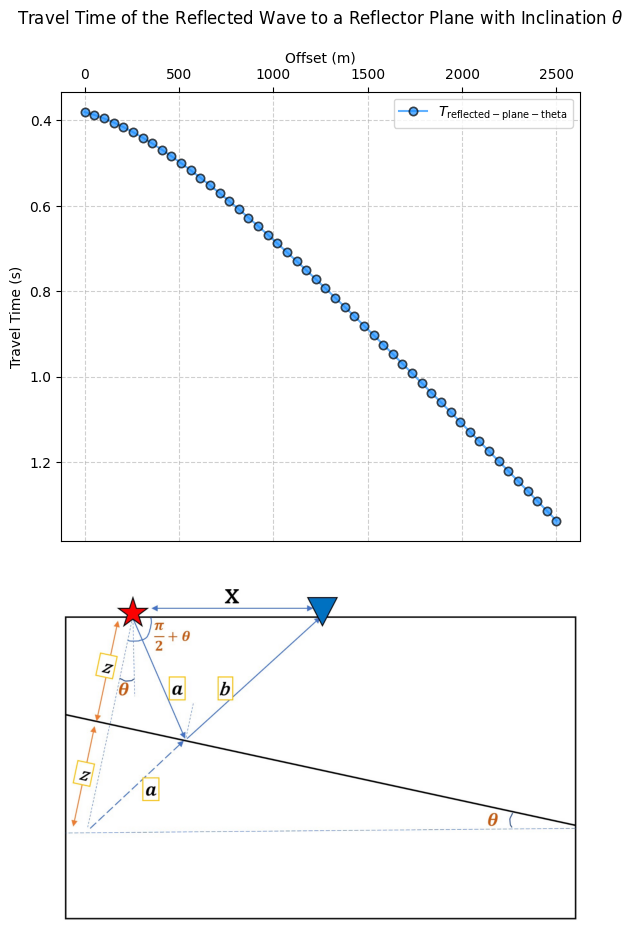

In [12]:
t_reflected_plane_theta=foward_reflected_plane_theta(x,v1,z,theta)
ploting_curves(x,t_reflected_plane_theta,'reflected-plane-theta',
               r'the Reflected Wave to a Reflector Plane with Inclination $\theta$',
               '05_1')


### 4) Travel time of the first-order multiple in plane reflectors with inclination $\theta$

$$ T_{\text{first-order-multiple-theta}} = \dfrac{\sqrt{(4z)^2+x^2+8\cdot z\cdot x\cdot \sin (\theta) }}{v_1}$$

In [13]:
def foward_first_order_multiple_theta(x,v1,z,theta):
    sqrt_theta=np.sqrt((4*z)**2+x**2+8*z*x*np.sin(theta))
    t_first_order_multiple_theta=sqrt_theta/v1
    return t_first_order_multiple_theta

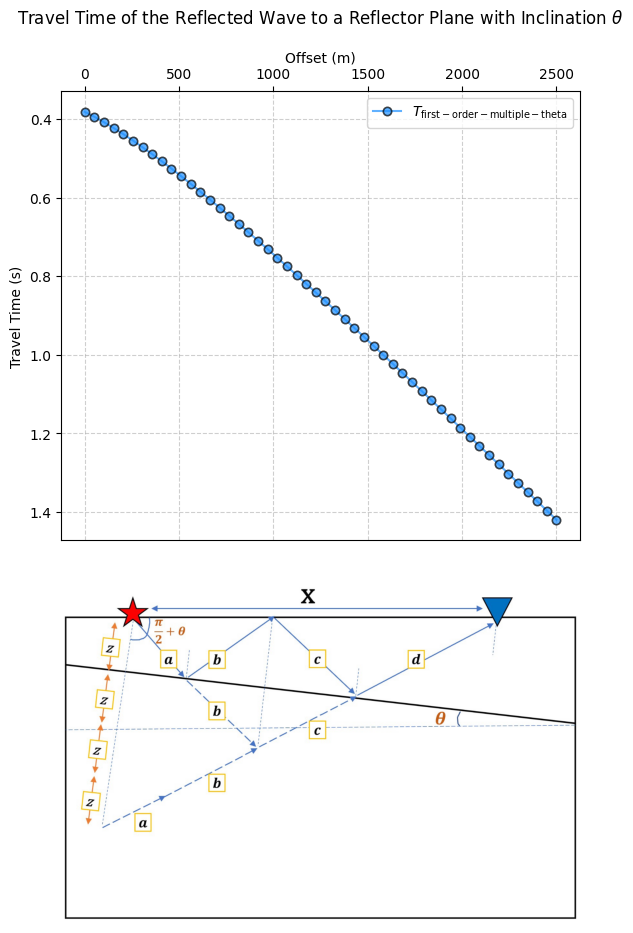

In [14]:
t_first_order_multiple_theta=foward_first_order_multiple_theta(x,v1,z,theta)

ploting_curves(x,t_first_order_multiple_theta,'first-order-multiple-theta',
               rf'the Reflected Wave to a Reflector Plane with Inclination $\theta$',
               '06_1')


### 5) Travel time of converted P-SV and SV-P waves in a medium with velocities $V_{p1}/V_{s1}$ and $V_{p2}/V_{s2}$

$$ T_{\text{P-SV}} = \dfrac{z_d}{v_{p1}\cdot \cos(\theta)}+\dfrac{z_u}{v_{s1}\cdot \cos(\phi)}$$


In [15]:
def foward_P_SV(zd,zu,vp1,vs1,theta,phi):
    t_P_SV=(zd/(vp1*np.cos(theta)))+(zu/(vs1*np.cos(phi)))
    return t_P_SV

$$ T_{\text{SV-P}} = \dfrac{z_d}{v_{s1}\cdot \cos(\phi)}+\dfrac{z_u}{v_{p1}\cdot \cos(\theta)}$$


In [16]:
def foward_SV_P(zd,zu,vp1,vs1,theta,phi):
    t_P_SV=(zd/(vs1*np.cos(phi)))+(zu/(vp1*np.cos(theta)))
    return t_P_SV

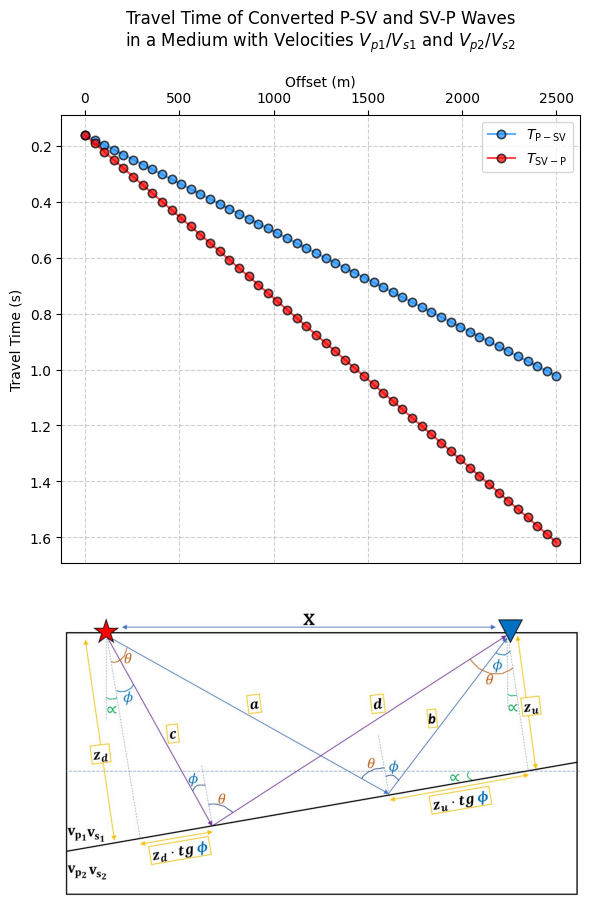

In [17]:
t_P_SV=foward_P_SV(zd,zu,vp1,vs1,theta,phi)
t_SV_P= foward_SV_P(zd,zu,vp1,vs1,theta,phi)

ploting_curves2(x,t_P_SV,t_SV_P,'\mathrm{P-SV}','\mathrm{SV-P}',
               r"""Converted P-SV and SV-P Waves
in a Medium with Velocities $V_{p1}/V_{s1}$ and $V_{p2}/V_{s2}$""", 
    '07_1')

### 6) Travel time of the refracted wave to a parallel plane reflector

$$ T_{\text{refraction}} = \dfrac{2\cdot}{v_{1}\cdot \cos(\theta_c)}+\dfrac{x-2\cdot z\cdot \tan(\theta_c)}{v_2}$$


In [18]:
def foward_refraction(x,v1,z,theta,v2):
    t_refraction=(2/(v1*np.cos(theta)))+((x-2*z*np.tan(theta))/v2)
    return t_refraction

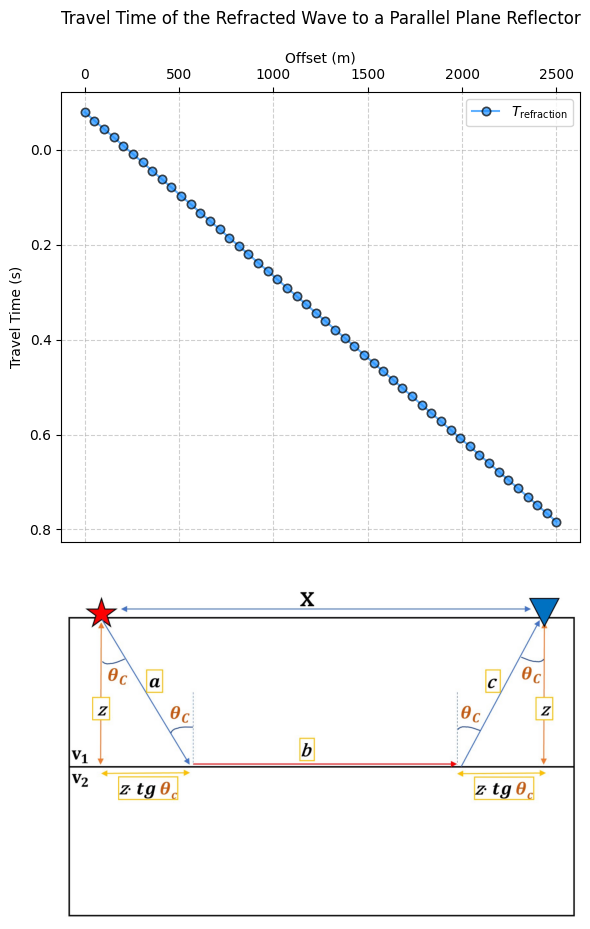

In [19]:
t_refraction=foward_refraction(x,v1,z,theta,v2)
ploting_curves(x,t_refraction,'refraction',
               rf'the Refracted Wave to a Parallel Plane Reflector',
               '08_1')

### 7) Travel time of the refracted wave to a plane reflector with inclination $\alpha$

$$ T_{\text{refraction}-\alpha} =\dfrac{z_d}{v_1 \cdot \cos(\theta_c)} + \dfrac{x \cdot \cos(\alpha) - z_d \cdot \tan(\theta_c) - (z_d - x \cdot \sin(\alpha)) \tan(\theta_c)}{v_2} + \dfrac{z_d - x \cdot \sin(\alpha)}{v_1 \cdot \cos(\theta_c)}$$


In [20]:
def foward_refracted_wave_alpha(zd,zu,vp1,vs1,theta,phi):
    t_refraction_alpha=(
        zd/(v1*np.cos(theta))+ (x*np.cos(alpha)-zd*np.tan(theta)-(zd-x*np.sin(alpha)*np.tan(theta)))/v2
        + (zd-x*np.sin(alpha))/(v1*np.cos(theta))
    )
    return t_refraction_alpha


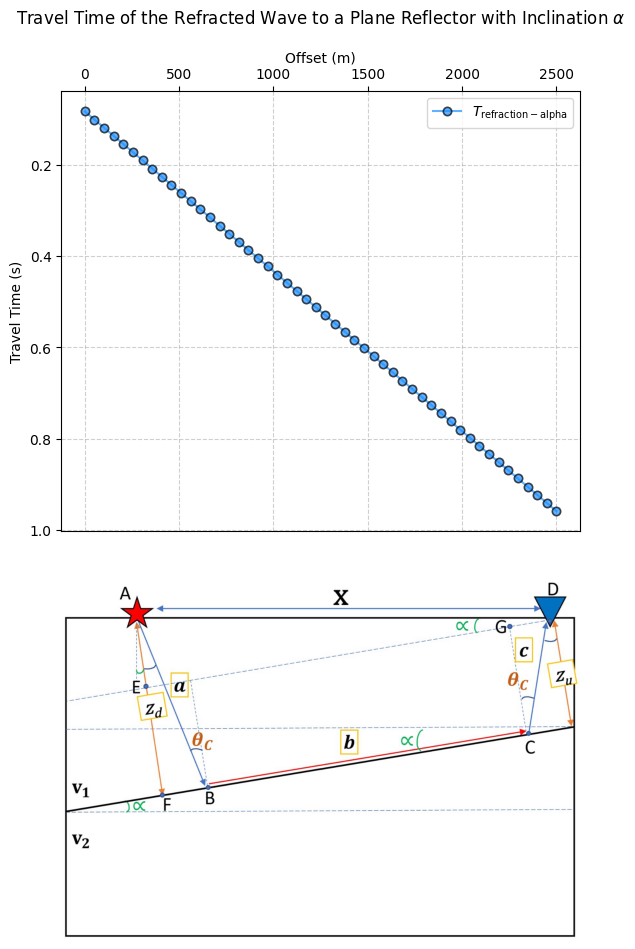

In [21]:
t_refraction_alpha=foward_refracted_wave_alpha(zd,zu,vp1,vs1,theta,phi)
ploting_curves(x,t_refraction_alpha,'refraction-alpha',
               rf'the Refracted Wave to a Plane Reflector with Inclination $\alpha$',
               '09_1')

### 8) Travel time for a diffracting event that is not located between the source and receiver

$$ T_{\mathrm{diffraction-not-between}} = \frac{\sqrt{(x + h)^2 + z^2}}{v} + \frac{\sqrt{(x - h)^2 + z^2}}{v} $$

In [22]:
def foward_difracted_wave_not(x,v1,z,h):
    sqrt_drifracted1=np.sqrt((x+h)**2+z**2)/v1
    sqrt_drifracted2=np.sqrt((x-h)**2+z**2)/v1
    t_difracted=sqrt_drifracted1+sqrt_drifracted2
    return t_difracted

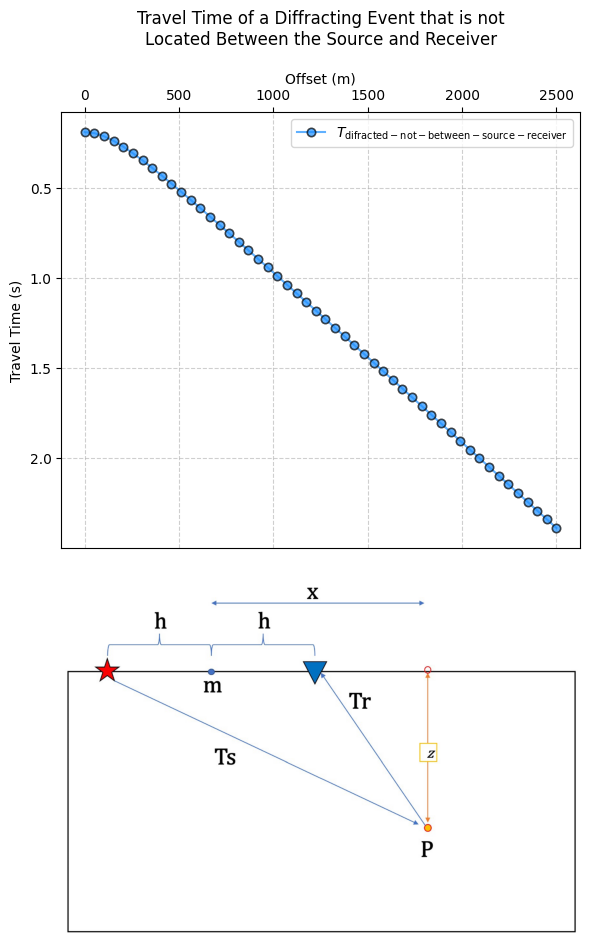

In [23]:
t_difracted_not=foward_difracted_wave_not(x,v1,z,h)
ploting_curves(x,t_difracted_not,'\mathrm{difracted-not-between-source-receiver}',
               rf'a Diffracting Event that is not'+ '\n' + 'Located Between the Source and Receiver',
               '10_1')

### 9) Travel time for a diffracting event located between source and receiver

$$T_{\mathrm{diffraction-between}} = \left( \frac{\sqrt{h_s^2 + z^2}}{v} \right) + \left( \frac{\sqrt{h_r^2 + z^2}}{v} \right)$$

In [24]:
def foward_difracted_wave_between(v1,z,hr,hs):
    sqrt_drifracted1=np.sqrt((hs)**2+z**2)/v1
    sqrt_drifracted2=np.sqrt((hr)**2+z**2)/v1
    t_difracted=sqrt_drifracted1+sqrt_drifracted2
    return t_difracted

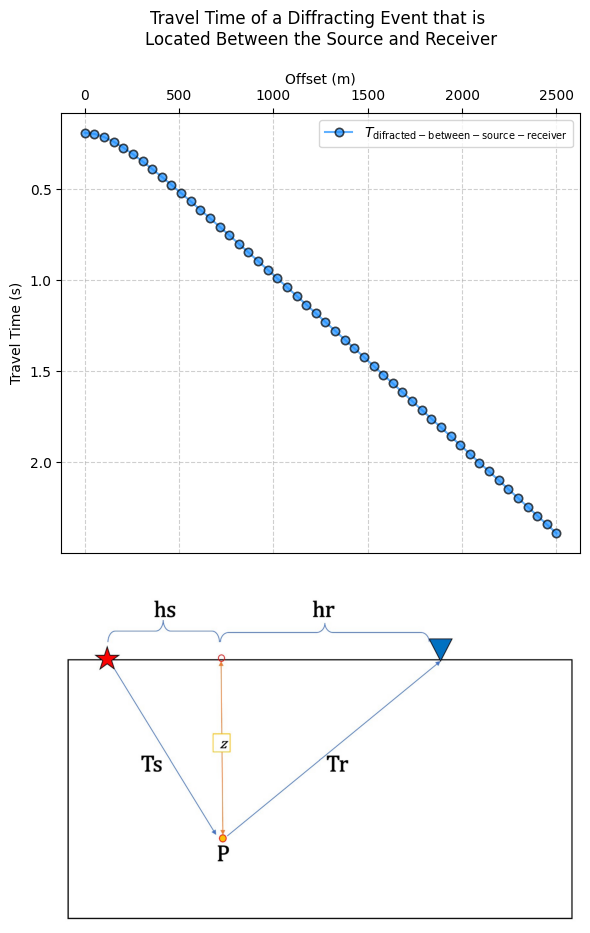

In [25]:
t_difracted_between=foward_difracted_wave_between(v1,z,hr,hs)
ploting_curves(x,t_difracted_between,'\mathrm{difracted-between-source-receiver}',
               rf'a Diffracting Event that is '+ '\n' + 'Located Between the Source and Receiver',
               '11_1')

### 10) Travel time for a model with a linear velocity gradient given by 
###                                 $v = v0 + az$

$$ t_{\text{gradient}} = \frac{1}{a} \log \left( \frac{v(z)}{v_0} \frac{1 + \sqrt{1 - p^2 v_0^2}}{1 + \sqrt{1 - p^2 v(z)^2}} \right) $$



In [26]:
def foward_gradient(v,p,v0):
    term_num = np.maximum(0, 1 - (p**2) * (v0**2))
    term_den = np.maximum(0, 1 - (p**2) * (v**2))

    numerator = v * (1 + np.sqrt(term_num))
    denominator = v0 * (1 + np.sqrt(term_den))
    
    t_gradient=(1/a)*np.log(numerator/denominator)
    return t_gradient

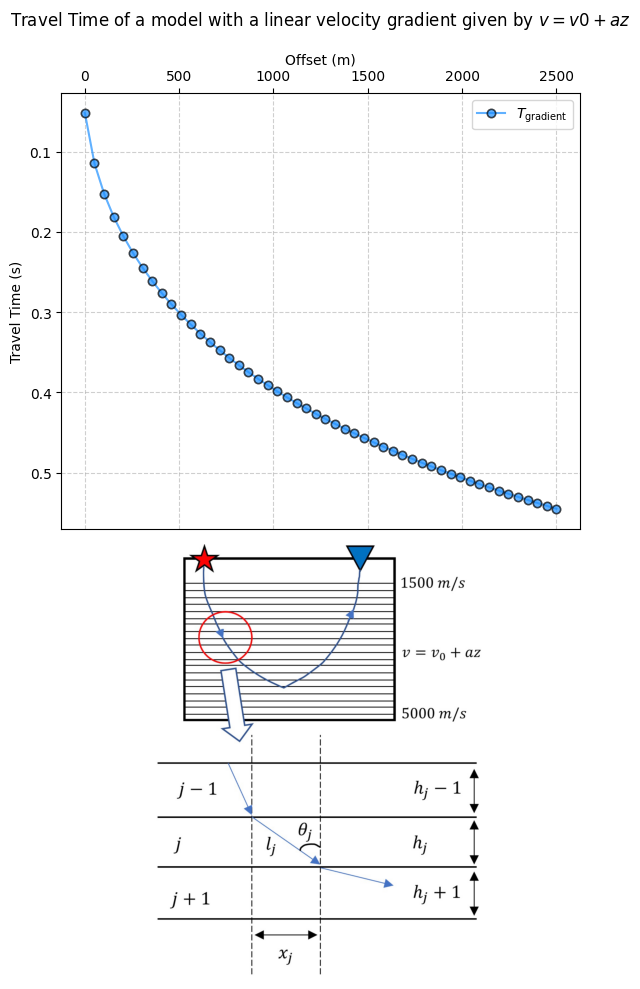

In [27]:
t_gradient=foward_gradient(v,p,v0)
ploting_curves(x,t_gradient,'\mathrm{gradient}',
               rf'a model with a linear velocity gradient given by $v = v0 + az$',
               '12_1')